In [8]:
#Data trnasformation
#1. Normalization(Min-Max Scaling)
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

data = pd.DataFrame({
    'A': [10, 20, 30, 40, 50],
    'B': [5, 15, 25, 35, 45]
})

scaler = MinMaxScaler()
normalized = scaler.fit_transform(data)
normalized_df = pd.DataFrame(normalized, columns=data.columns)

print("Normalized Data:\n", normalized_df)


Normalized Data:
       A     B
0  0.00  0.00
1  0.25  0.25
2  0.50  0.50
3  0.75  0.75
4  1.00  1.00


In [10]:
#2. Standardization (Z-Score)
import pandas as pd
from sklearn.preprocessing import StandardScaler

data = pd.DataFrame({
    'A': [10, 20, 30, 40, 50],
    'B': [5, 15, 25, 35, 45]
})

scaler = StandardScaler()
standardized = scaler.fit_transform(data)
standardized_df = pd.DataFrame(standardized, columns=data.columns)

print("Standardized Data:\n", standardized_df)


Standardized Data:
           A         B
0 -1.414214 -1.414214
1 -0.707107 -0.707107
2  0.000000  0.000000
3  0.707107  0.707107
4  1.414214  1.414214


In [11]:
#3. Encoding Categorical Variables (One-Hot)
import pandas as pd

df = pd.DataFrame({'Color': ['Red', 'Blue', 'Green', 'Red', 'Blue']})
one_hot = pd.get_dummies(df, columns=['Color'])

print("One-Hot Encoding:\n", one_hot)


One-Hot Encoding:
    Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3       False        False       True
4        True        False      False


Explained variance ratio: [0.72627656 0.1730423 ]
        PC1       PC2
0 -1.348415  0.426746
1 -0.955740  1.093576
2  0.540971  0.122324
3  0.067789 -0.674616
4  1.408308  0.847661


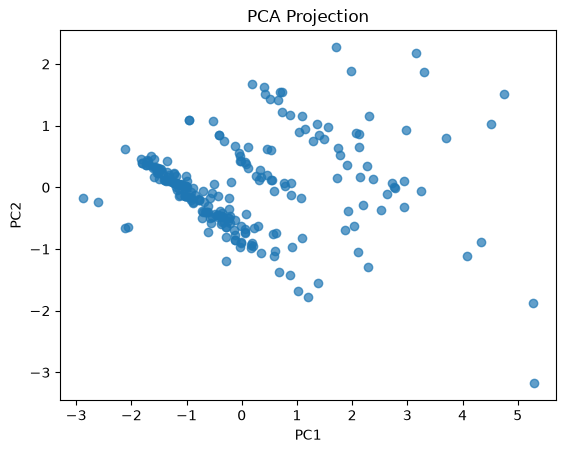

In [17]:
#Dimensionality Reduction
#1. Principal Component Analysis (PCA)
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")
numeric_cols = tips.select_dtypes(include=['float64','int64'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_cols)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_result, columns=['PC1','PC2'])
print("Explained variance ratio:", pca.explained_variance_ratio_)
print(pca_df.head())

plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCA Projection')
plt.show()

Explained variance ratio: [0.9912126 0.0087874]
        LD1       LD2  target
0  8.143648 -0.303471       0
1  7.201062  0.794647       0
2  7.565869  0.268079       0
3  6.882372  0.677440       0
4  8.214873 -0.519686       0


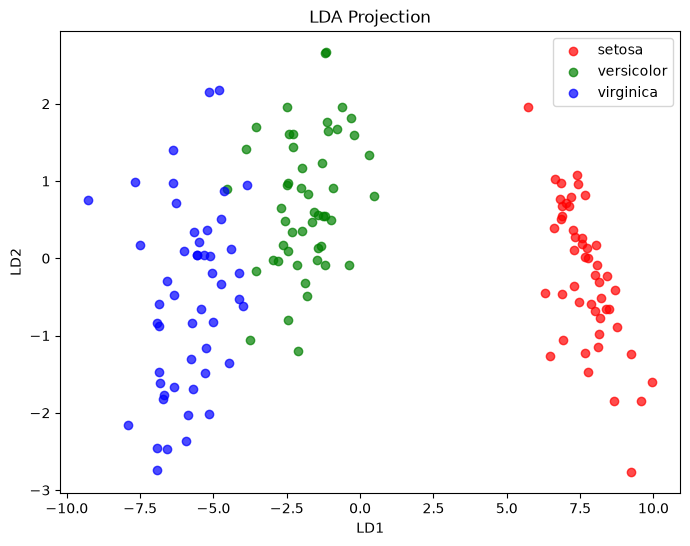

In [13]:
#2. Linear Discriminant Analysis (LDA)
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt

iris = load_iris()
X, y = iris.data, iris.target

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

lda_df = pd.DataFrame(X_lda, columns=['LD1','LD2'])
lda_df['target'] = y
print("Explained variance ratio:", lda.explained_variance_ratio_)
print(lda_df.head())

plt.figure(figsize=(8,6))
for label, color in zip([0,1,2], ['red','green','blue']):
    plt.scatter(
        lda_df.loc[lda_df['target']==label, 'LD1'],
        lda_df.loc[lda_df['target']==label, 'LD2'],
        label=iris.target_names[label],
        color=color, alpha=0.7
    )
plt.xlabel('LD1'); plt.ylabel('LD2')
plt.title('LDA Projection')
plt.legend(); plt.show()


       TSNE1     TSNE2  target
0 -23.906771 -1.995415       0
1 -21.192930 -1.171225       0
2 -21.470705 -2.352272       0
3 -20.972347 -2.005782       0
4 -23.955744 -2.416308       0


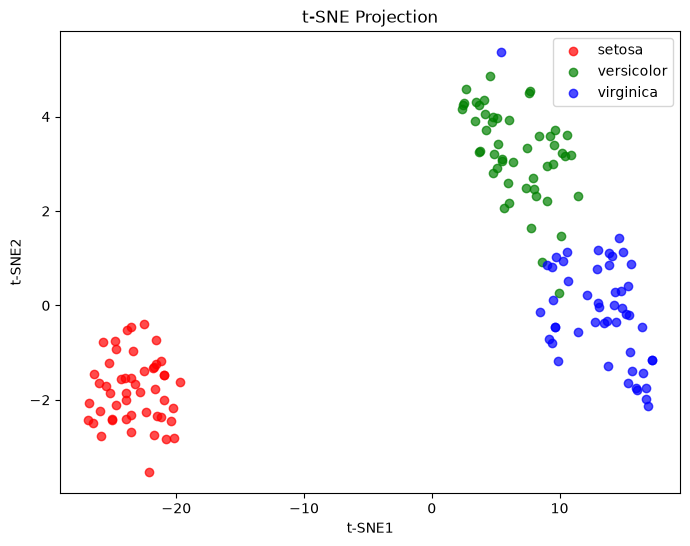

In [14]:
#3. t-SNE
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

iris = load_iris()
X, y = iris.data, iris.target

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X)

tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1','TSNE2'])
tsne_df['target'] = y
print(tsne_df.head())

plt.figure(figsize=(8,6))
for label, color in zip([0,1,2], ['red','green','blue']):
    plt.scatter(
        tsne_df.loc[tsne_df['target']==label, 'TSNE1'],
        tsne_df.loc[tsne_df['target']==label, 'TSNE2'],
        label=iris.target_names[label],
        color=color, alpha=0.7
    )
plt.xlabel('t-SNE1'); plt.ylabel('t-SNE2')
plt.title('t-SNE Projection')
plt.legend(); plt.show()
